c:\Users\rlith\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.2240 - loss: 1.9168
Epoch 1: val_accuracy improved from -inf to 0.72000, saving model to epoch_two_five_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - accuracy: 0.2249 - loss: 1.9148 - val_accuracy: 0.7200 - val_loss: 0.8792
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.6655 - loss: 0.8993
Epoch 2: val_accuracy improved from 0.72000 to 0.84000, saving model to epoch_two_five_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.6656 - loss: 0.8988 - val_accuracy: 0.8400 - val_loss: 0.4609
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7485 - loss: 0.6705
Epoch 3: val_accuracy improved from 0.84000 to 0.84250, saving model to epoch_two_five_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 211ms/step - accuracy: 0.7486 - loss: 0.6704 - val_accuracy: 0.8425 - val_loss: 0.4126
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7756 - loss: 0

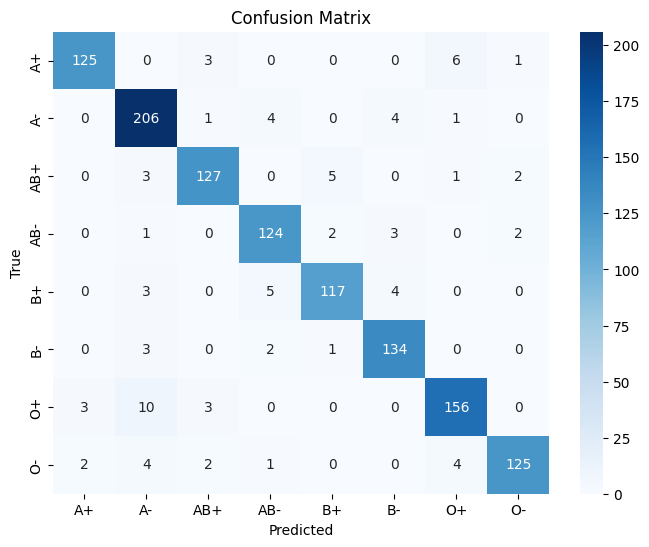

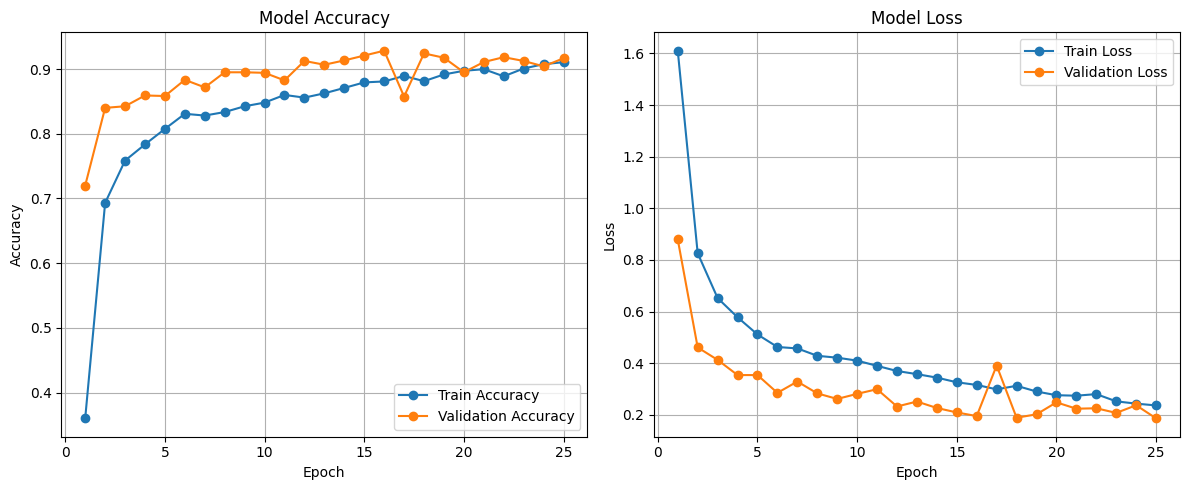

In [ ]:

#-------25 EPOCH CNN MODEL --------------

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Constants
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 25   
NUM_CLASSES = 8

label_map = {
    'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3,
    'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7
}
inv_label_map = {v: k for k, v in label_map.items()}

# Load dataset
def load_data(data_dir):
    images, labels = [], []
    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path) and label in label_map:
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        img = img.astype('float32') / 255.0
                        images.append(img)
                        labels.append(label_map[label])
                except Exception as e:
                    print(f"Error reading {img_path}: {e}")
    return np.array(images), np.array(labels)

data_dir = r'C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE_FINAL\dataset_blood_group'
X, y = load_data(data_dir)

if len(X) == 0:
    raise ValueError("No images found. Check dataset path.")

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_categorical = to_categorical(y, num_classes=NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Model architecture
def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model = build_model()
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model checkpoint - save in new Keras format
checkpoint_path = "epoch_two_five_model.keras"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)

# Train model & capture history
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint],
    verbose=1
)

# ✅ Save training history for reuse
with open("epoch_two_five_training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

# Load best model and evaluate
model = tf.keras.models.load_model(checkpoint_path)
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Accuracy & Loss Graphs
epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()





In [ ]:
#-------ACCURACY & LOSS---------------


import pickle

# Load the saved history
with open("epoch_two_five_training_history.pkl", "rb") as f:
    history_data = pickle.load(f)

# Epoch indexing starts from 0 → so 25th epoch = index 24
epoch_num = 25
train_acc = history_data['accuracy'][epoch_num - 1]
val_acc = history_data['val_accuracy'][epoch_num - 1]
train_loss = history_data['loss'][epoch_num - 1]
val_loss = history_data['val_loss'][epoch_num - 1]

print(f"Epoch {epoch_num} Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Epoch 25 Results:
Training Accuracy: 0.9508
Validation Accuracy: 0.9217
Training Loss: 0.1378
Validation Loss: 0.2046


GRAPHS

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


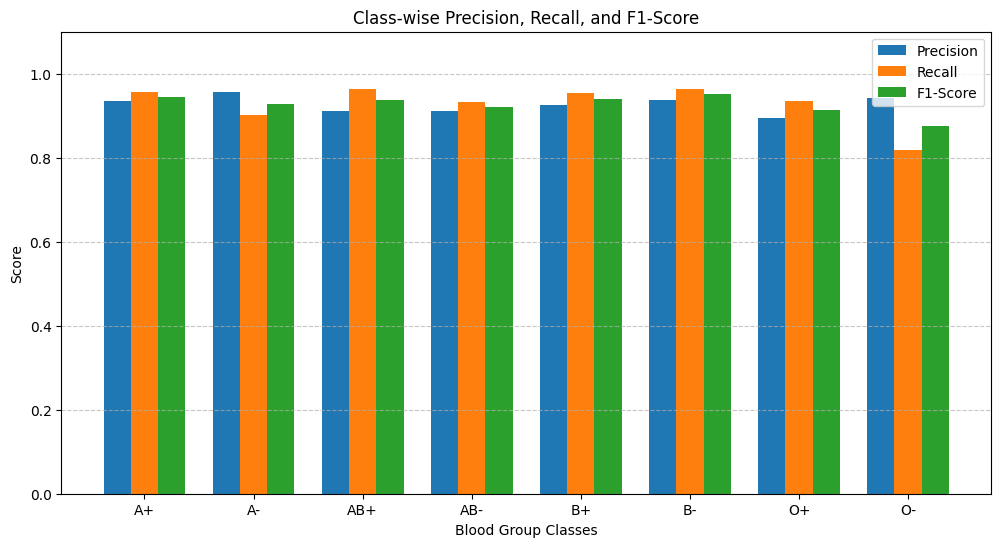

In [ ]:
# --- CLASSWISE CLASSIFICATION REPORT ---

import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Constants
IMG_SIZE = 128
NUM_CLASSES = 8

label_map = {
    'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3,
    'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7
}

# Redefine the function to load images
def load_data(data_dir):
    images, labels = [], []
    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path) and label in label_map:
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        img = img.astype('float32') / 255.0
                        images.append(img)
                        labels.append(label_map[label])
                except Exception as e:
                    print(f"Error reading {img_path}: {e}")
    return np.array(images), np.array(labels)

# Load dataset
data_dir = r'C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE\dataset_blood_group'
X, y = load_data(data_dir)

# Preprocess
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_categorical = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

# Load trained model
model = tf.keras.models.load_model("epoch_two_five_model.keras")

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
report_dict = classification_report(y_true, y_pred, target_names=label_map.keys(), output_dict=True)

# Bar graph
classes = list(label_map.keys())
precision = [report_dict[c]['precision'] for c in classes]
recall = [report_dict[c]['recall'] for c in classes]
f1 = [report_dict[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

# plt.figure(figsize=(12,6))
# plt.bar(x - width, precision, width, label='Precision', color='skyblue')
# plt.bar(x, recall, width, label='Recall', color='lightgreen')
# plt.bar(x + width, f1, width, label='F1-Score', color='salmon')

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')

plt.xlabel('Blood Group Classes')
plt.ylabel('Score')
plt.title('Class-wise Precision, Recall, and F1-Score')
plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


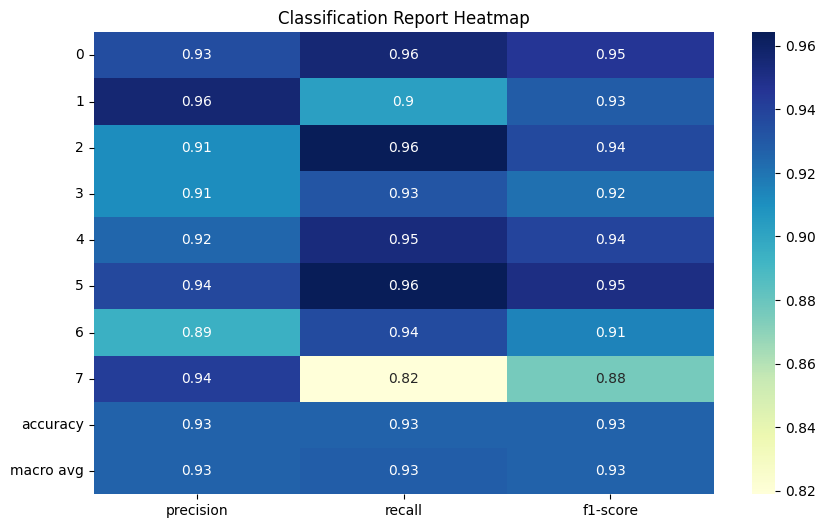

In [11]:
import pandas as pd
import seaborn as sns

# --- CLASSIFICATION REPORT HEATMAP ---
report = classification_report(y_true, y_pred, target_names=label_map.values(), output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlGnBu')
plt.title("Classification Report Heatmap")
plt.show()

SAMPLE PREDICTION

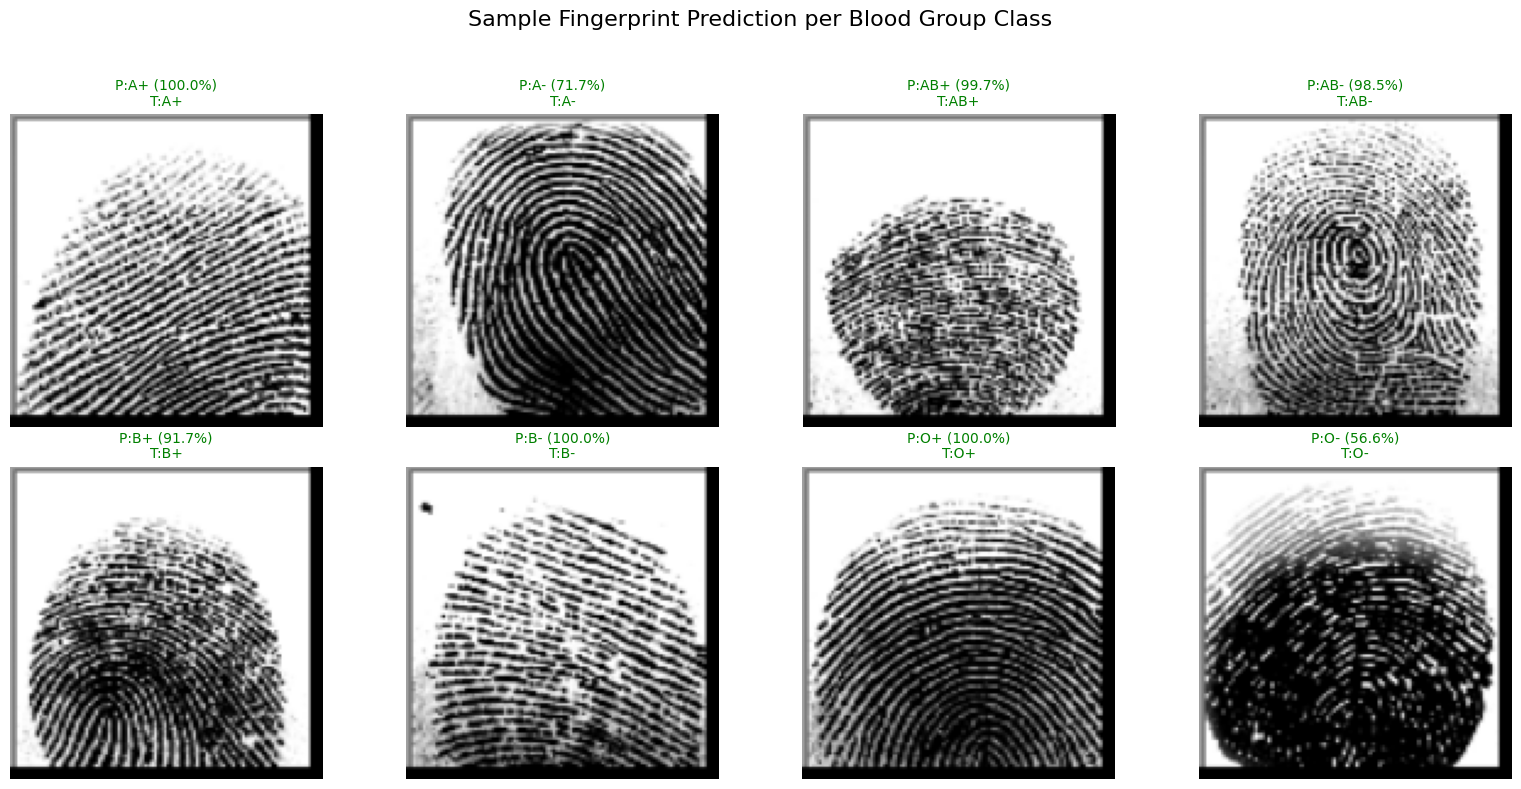

In [ ]:
#--------------SAMPLE PREDICTION VISUALIZATION PER CLASS------

import matplotlib.pyplot as plt
import numpy as np

# Define inverse label map if not already defined
inv_label_map = {v: k for k, v in label_map.items()}

plt.figure(figsize=(16, 8))

for class_idx, class_name in enumerate(label_map.keys()):
    # Find indices in test set belonging to this class
    indices = np.where(y_true == class_idx)[0]
    
    if len(indices) == 0:
        continue  # skip if no example for this class
    
    # Pick a random sample from this class
    idx = np.random.choice(indices)
    
    plt.subplot(2, 4, class_idx + 1)
    plt.imshow(X_test[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    
    pred_label = inv_label_map[y_pred[idx]]
    true_label = inv_label_map[y_true[idx]]
    confidence = np.max(y_pred_probs[idx]) * 100
    color = "green" if pred_label == true_label else "red"
    
    plt.title(f"P:{pred_label} ({confidence:.1f}%)\nT:{true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Fingerprint Prediction per Blood Group Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


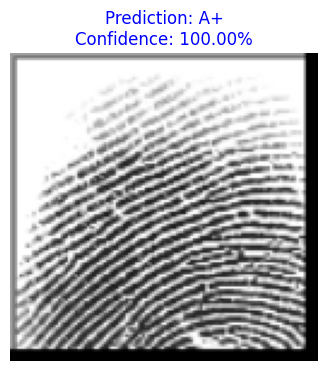

In [ ]:
#------------SAMPLE PREDICTION FOR SINGLE IMAGE-----------------

import matplotlib.pyplot as plt
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# ---------------- CONFIG ----------------
IMG_SIZE = 128  # Set according to your model
CLASSES = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']

# Load your trained model
import tensorflow as tf
model = tf.keras.models.load_model("epoch_two_five_model.keras")

# Optional: If you have a label map dictionary
label_map = {name: i for i, name in enumerate(CLASSES)}
inv_label_map = {v: k for k, v in label_map.items()}

# ---------------- INPUT IMAGE ----------------
image_path = r"C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE\dataset_blood_group\A+\cluster_0_16.BMP"  # Provide your image path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_input = img_resized.reshape(1, IMG_SIZE, IMG_SIZE, 1) / 255.0  # Normalize

# ---------------- PREDICTION ----------------
y_pred_probs = model.predict(img_input)
pred_class_idx = np.argmax(y_pred_probs)
pred_label = inv_label_map[pred_class_idx]
confidence = y_pred_probs[0][pred_class_idx] * 100

# ---------------- DISPLAY ----------------
plt.figure(figsize=(4, 4))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Prediction: {pred_label}\nConfidence: {confidence:.2f}%", fontsize=12, color="blue")
plt.axis('off')
plt.show()


GRADCAM TESTING success
GRADCAM PREDICTION 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


c:\Users\rlith\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_54']
Received: inputs=Tensor(shape=(1, 128, 128, 1))
  warnings.warn(msg)


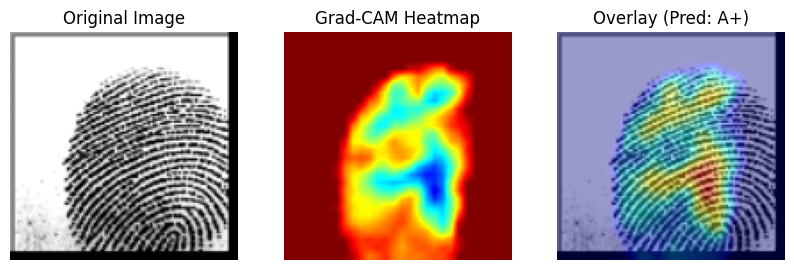

In [19]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------------- CONFIG ----------------
IMG_SIZE = 128
NUM_CLASSES = 8
WEIGHTS_PATH = r"epoch_two_five_model.keras"  # path to your saved weights
LAST_CONV_LAYER_NAME = "last_conv"

# ---------------- LABELS ----------------
label_map = {
    'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3,
    'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7
}
inv_label_map = {v: k for k, v in label_map.items()}

# ---------------- FUNCTIONAL MODEL ----------------
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(128, (3, 3), activation='relu', name=LAST_CONV_LAYER_NAME)(x)
x = MaxPooling2D(2, 2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Load saved weights
model.load_weights(WEIGHTS_PATH)

# ---------------- GRADCAM UTILITIES ----------------
def get_img_array(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)  # (H,W,1)
    img = np.expand_dims(img, axis=0)   # (1,H,W,1)
    return img

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = Model([model.input], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, alpha=0.4):
    img_array = get_img_array(img_path)
    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    
    heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER_NAME, pred_index=pred_class)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_color)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Overlay (Pred: {inv_label_map[pred_class]})")
    plt.axis("off")
    plt.show()

# ---------------- TEST GRADCAM for  Single image----------------
test_image_path = r"C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE\dataset_blood_group\A+\cluster_0_3461.BMP"
display_gradcam(test_image_path)

# ---------------- OPTIONAL: Generate GradCAM for all test images ----------------
# test_dir = r"C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE\dataset_blood_group\A-"
# for img_file in os.listdir(test_dir):
#     img_path = os.path.join(test_dir, img_file)
#     display_gradcam(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


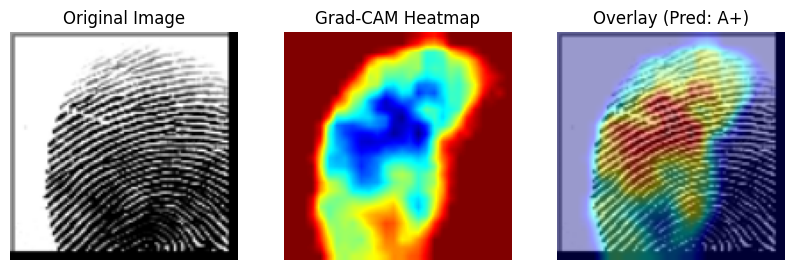

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


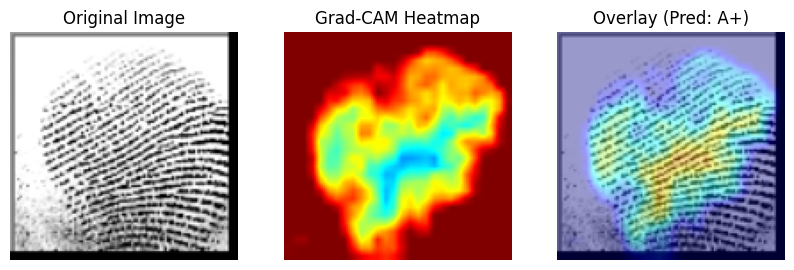

In [ ]:
#---FOR TESTING MORE IMAGES-----------
#---------------- OPTIONAL: Generate GradCAM for all test images- I have generated for 20 images----------------
test_dir = r"C:\FINAL_YEAR_PRO\FINAL_MINI_SCORE\dataset_blood_group\A+"
c = 0
for img_file in os.listdir(test_dir):
    c+=1
    img_path = os.path.join(test_dir, img_file)
    display_gradcam(img_path)
    if(c==2):
        break

In [ ]:
#-------ACCURACY & LOSS---------------

import pickle

# Load the saved history
with open("epoch_two_five_training_history.pkl", "rb") as f:
    history_data = pickle.load(f)

# Epoch indexing starts from 0 → so 25th epoch = index 24
epoch_num = 25
train_acc = history_data['accuracy'][epoch_num - 1]
val_acc = history_data['val_accuracy'][epoch_num - 1]
train_loss = history_data['loss'][epoch_num - 1]
val_loss = history_data['val_loss'][epoch_num - 1]

print(f"Epoch {epoch_num} Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Epoch 25 Results:
Training Accuracy: 0.9508
Validation Accuracy: 0.9217
Training Loss: 0.1378
Validation Loss: 0.2046


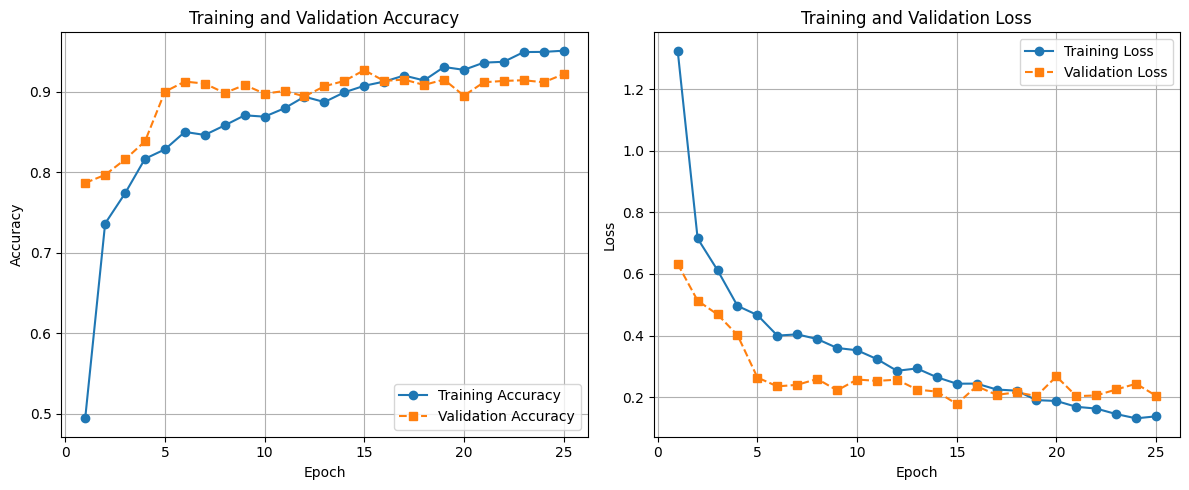

In [3]:
import pickle
import matplotlib.pyplot as plt

# Load training history
with open("epoch_two_five_training_history.pkl", "rb") as f:
    history = pickle.load(f)

epochs = range(1, len(history['accuracy']) + 1)

# Create side-by-side subplots
plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], marker='o', linestyle='-', label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], marker='s', linestyle='--', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], marker='o', linestyle='-', label='Training Loss')
plt.plot(epochs, history['val_loss'], marker='s', linestyle='--', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



PAPER 2 GRAPH

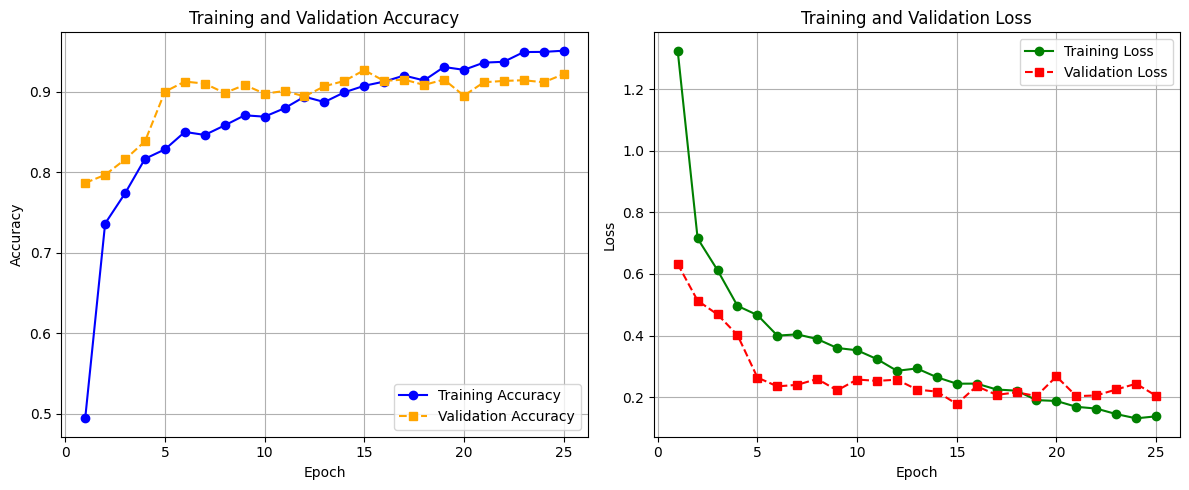

In [4]:
import pickle
import matplotlib.pyplot as plt

# Load training history
with open("epoch_two_five_training_history.pkl", "rb") as f:
    history = pickle.load(f)

epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(
    epochs, history['accuracy'],
    color='blue', marker='o', linestyle='-',
    label='Training Accuracy'
)
plt.plot(
    epochs, history['val_accuracy'],
    color='orange', marker='s', linestyle='--',
    label='Validation Accuracy'
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(
    epochs, history['loss'],
    color='green', marker='o', linestyle='-',
    label='Training Loss'
)
plt.plot(
    epochs, history['val_loss'],
    color='red', marker='s', linestyle='--',
    label='Validation Loss'
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Hybrid CNN + Swin + Grad-CAM++ with optimizations

In [ ]:

# ==== prediction.ipynb (hybrid CNN + Swin + Grad-CAM++ with optimizations) ====
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     Input, GlobalAveragePooling2D, Reshape, LayerNormalization,
                                     MultiHeadAttention, Add, DepthwiseConv2D, Activation, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import itertools

try:
    import seaborn as sns
    _HAS_SNS = True
except:
    _HAS_SNS = False

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 40

label_map = {
    'A+':  0,'A-':  1,'AB+': 2,'AB-': 3,'B+':  4,'B-':  5,'O+':  6,'O-':  7
}
idx_to_label = {v:k for k,v in label_map.items()}

def load_data(data_dir):
    images, labels = [], []
    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path) and label in label_map:
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        images.append(img)
                        labels.append(label_map[label])
                except Exception as e:
                    print(f"Error reading {img_path}: {e}")
    images = np.array(images).astype('float32') / 255.0
    labels = np.array(labels)
    return images, labels

data_dir = r'C:\Users\Jayalakshmi\Desktop\final year project\blood group detection using fingerprint\source code\dataset_blood_group'
X, y = load_data(data_dir)

if len(X) == 0:
    raise ValueError("No images found. Check your dataset folder path and structure.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test  = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_train = to_categorical(y_train, num_classes=8)
y_test  = to_categorical(y_test,  num_classes=8)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

def window_partition(x, window_size):
    B, H, W, C = tf.unstack(tf.shape(x))
    x = tf.reshape(x, [B, H // window_size, window_size, W // window_size, window_size, C])
    x = tf.transpose(x, [0,1,3,2,4,5])
    windows = tf.reshape(x, [B * (H // window_size) * (W // window_size), window_size, window_size, C])
    return windows

def window_reverse(windows, window_size, H, W, C):
    B = tf.shape(windows)[0] // ( (H // window_size) * (W // window_size) )
    x = tf.reshape(windows, [B, H // window_size, W // window_size, window_size, window_size, C])
    x = tf.transpose(x, [0,1,3,2,4,5])
    x = tf.reshape(x, [B, H, W, C])
    return x

def mlp(x, hidden_units, drop_rate=0.0):
    for units in hidden_units:
        x = Dense(units, activation='gelu')(x)
        if drop_rate > 0:
            x = Dropout(drop_rate)(x)
    return x

# ...existing code...

class SwinBlock(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads, window_size=4, mlp_ratio=4, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.mlp_ratio = mlp_ratio
        self.drop_rate = drop_rate

        self.norm1 = LayerNormalization(epsilon=1e-5)
        self.attn = MultiHeadAttention(num_heads=num_heads, key_dim=dim//num_heads)
        self.drop1 = Dropout(drop_rate)
        self.norm2 = LayerNormalization(epsilon=1e-5)
        self.mlp_hidden = int(mlp_ratio * dim)

        # Define MLP layers ONCE here
        self.mlp_dense1 = Dense(self.mlp_hidden, activation='gelu')
        self.mlp_drop1 = Dropout(drop_rate)
        self.mlp_dense2 = Dense(dim)
        self.mlp_drop2 = Dropout(drop_rate)

    def call(self, x):
        H, W = x.shape[1], x.shape[2]
        C = x.shape[3]
        shortcut = x
        x = self.norm1(x)
        windows = window_partition(x, self.window_size)
        ws = self.window_size
        windows_flat = tf.reshape(windows, [-1, ws*ws, C])
        attn_out = self.attn(windows_flat, windows_flat)
        attn_out = self.drop1(attn_out)
        attn_out = tf.reshape(attn_out, [-1, ws, ws, C])
        x = window_reverse(attn_out, self.window_size, H, W, C)
        x = Add()([shortcut, x])
        shortcut2 = x
        x = self.norm2(x)
        x = tf.reshape(x, [-1, H*W, C])
        # Use pre-defined MLP layers
        x = self.mlp_dense1(x)
        x = self.mlp_drop1(x)
        x = self.mlp_dense2(x)
        x = self.mlp_drop2(x)
        x = tf.reshape(x, [-1, H, W, C])
        x = Add()([shortcut2, x])
        return x

# ...existing code...

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="input_img")
x = Conv2D(32, (3,3), activation='relu', padding='same', name="stem_conv1")(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), name="stem_pool1")(x)
x = Conv2D(64, (3,3), activation='relu', padding='same', name="stem_conv2")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), name="stem_pool2")(x)
x = Conv2D(128,(3,3), activation='relu', padding='same', name="stem_conv3")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), name="stem_pool3")(x)
x = DepthwiseConv2D(3, padding='same', name='pre_swin_dw')(x)
x = Activation('relu')(x)
x = SwinBlock(dim=128, num_heads=4, window_size=4, mlp_ratio=4, drop_rate=0.1, name="swin_block_1")(x)
x = SwinBlock(dim=128, num_heads=4, window_size=4, mlp_ratio=4, drop_rate=0.1, name="swin_block_2")(x)
gap = GlobalAveragePooling2D(name="gap")(x)
fc = Dense(256, activation='relu', name="fc")(gap)
fc = BatchNormalization()(fc)
drop = Dropout(0.5, name="drop")(fc)
outputs = Dense(8, activation='softmax', name="predictions")(drop)
model = Model(inputs, outputs, name="cnn_swin_bloodgroup")

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[reduce_lr, early_stop],
    steps_per_epoch=len(X_train)//BATCH_SIZE
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
labels_order = list(label_map.keys())

plt.figure(figsize=(7,6))
if _HAS_SNS:
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order)
else:
    plt.imshow(cm, interpolation='nearest')
    plt.colorbar()
    tick_marks = np.arange(len(labels_order))
    plt.xticks(tick_marks, labels_order, rotation=45)
    plt.yticks(tick_marks, labels_order)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

model.save('blood_group_model.h5')
print("Saved model to blood_group_model.h5")

def grad_cam_plus_plus(img_array, model, class_index, layer_name=None):
    if layer_name is None:
        layer_name = 'stem_conv3'
    conv_layer = model.get_layer(layer_name).output
    grad_model = tf.keras.models.Model([model.inputs], [conv_layer, model.output])
    with tf.GradientTape(persistent=True) as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]
    grads = tape.gradient(loss, conv_outputs)
    grads2 = tape.gradient(loss, conv_outputs)
    grads3 = tape.gradient(loss, conv_outputs)
    del tape
    numerator = grads2
    denominator = 2.0 * grads2 + tf.reduce_sum(conv_outputs * grads3, axis=(1,2), keepdims=True)
    denominator = tf.where(tf.equal(denominator, 0.0), tf.ones_like(denominator), denominator)
    alphas = numerator / denominator
    weights = tf.nn.relu(grads) * alphas
    weights = tf.reduce_sum(weights, axis=(1,2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(weights * conv_outputs, axis=-1))
    cam = cam[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam

sample = X_test[0:1]
pred = model.predict(sample)
cix = int(np.argmax(pred[0]))
heat = grad_cam_plus_plus(sample, model, cix, layer_name='stem_conv3')

plt.figure()
plt.imshow(sample[0].squeeze(), cmap='gray')
plt.imshow(heat, alpha=0.5)
plt.title(f"Grad-CAM++ Overlay: Pred {idx_to_label[cix]}")
plt.axis('off')
plt.show()




